# Análise dos datasets EvoSuite — limpeza + testes estatísticos

Notebook único para **Google Colab**. Os dados são baixados direto do GitHub (raw),
sem arquivos locais.

- **Parte 1 — Limpeza por projeto:** deduplica execuções repetidas, mantém apenas
  projetos presentes nos dois datasets e colapsa cada projeto em uma linha
  (numéricas → média, categóricas → primeiro valor). Gera os CSVs limpos + resumo.
- **Parte 2 — Testes estatísticos:** comparação pareada por projeto de `countMajor`
  (com testes vs sem testes, e variantes + EvoSuite / + Kex) usando o teste de
  Wilcoxon com tamanho de efeito rank-biserial de Pratt.

> Mapeamento: `final_native.csv` = **with tests**, `final_without_tests.csv` = **without tests**.

## 0 Setup e carregamento dos dados (compartilhado)

Baixa todos os datasets do repositório. As duas partes reutilizam estes dataframes.

In [1]:
%pip install -q pandas scipy

In [2]:
import pandas as pd

BASE = "https://raw.githubusercontent.com/SuelenFelix/analise-geracao-testes/main/results_safer"

# --- datasets base ---
df_without_tests = pd.read_csv(f"{BASE}/final_without_tests.csv")
df_all = pd.read_csv(f"{BASE}/final_all_tests.csv")
df_native = pd.read_csv(f"{BASE}/final_native.csv")
df_native_evo = pd.read_csv(f"{BASE}/final_native_evosuite.csv")
df_native_kex = pd.read_csv(f"{BASE}/final_native_kex.csv")
df_kex = pd.read_csv(f"{BASE}/final_only_kex.csv")
df_evo = pd.read_csv(f"{BASE}/final_only_evosuite.csv")
df_kex_evo = pd.read_csv(f"{BASE}/final_evosuite_kex.csv")

# --- aliases / variantes usadas na Parte 2 ---
df_with_tests = df_native


df_with_tests_plus_evosuite = pd.read_csv(
    f"{BASE}/final_native_evosuite.csv", na_values="-"
).fillna(0.0)

df_with_tests_plus_kex = pd.read_csv(
    f"{BASE}/final_native_kex.csv", na_values="-"
).fillna(0.0)
df_with_tests_plus_kex["Project Name"] = df_with_tests_plus_kex["Project Name"].replace(
    "kyungseo_project-web-starter39", "kyungseo_project-web-starter"
)

print("with tests (native): ", df_with_tests.shape)
print("without tests:       ", df_without_tests.shape)
print("with tests + evosuite:", df_with_tests_plus_evosuite.shape)
print("with tests + kex:     ", df_with_tests_plus_kex.shape)

with tests (native):  (183, 26)
without tests:        (211, 26)
with tests + evosuite: (214, 26)
with tests + kex:      (107, 26)


# Parte 1 — Limpeza por projeto

## 1.1 Configuração (colunas-chave, numéricas e categóricas)

In [3]:
PROJECT_KEY = "Project Name"

# Chave lógica: duas linhas com os mesmos valores aqui são a "mesma" execução.
ROW_KEY_COLUMNS = [
    "Project Name",
    "Number of dependencies with vulnerabilities (Before)",
    "Number of dependencies with vulnerabilities (After)",
    "Number of vulnerabilities (Before)",
    "Number of vulnerabilities (After)",
    "Low vulnerabilities (Before)",
    "Low vulnerabilities (After)",
    "Medium vulnerabilities (Before)",
    "Medium vulnerabilities (After)",
    "High vulnerabilities (Before)",
    "High vulnerabilities (After)",
    "Critical vulnerabilities (Before)",
    "Critical vulnerabilities (After)",
    "Build Tool",
    "Tests",
    "Project Type",
    "Improved",
    "javaVersion",
    "countMajor",
    "countMinor",
    "countPatch",
    "countPrerelease",
    "countBuildmetadata",
]

# Colunas tratadas como numéricas (média por projeto).
NUMERIC_COLUMNS = [
    "Number of dependencies with vulnerabilities (Before)",
    "Number of dependencies with vulnerabilities (After)",
    "Number of vulnerabilities (Before)",
    "Number of vulnerabilities (After)",
    "Low vulnerabilities (Before)",
    "Low vulnerabilities (After)",
    "Medium vulnerabilities (Before)",
    "Medium vulnerabilities (After)",
    "High vulnerabilities (Before)",
    "High vulnerabilities (After)",
    "Critical vulnerabilities (Before)",
    "Critical vulnerabilities (After)",
    "Execution Time (s)",
    "javaVersion",
    "countMajor",
    "countMinor",
    "countPatch",
    "countPrerelease",
    "countBuildmetadata",
]

# Colunas categóricas (primeiro valor observado).
CATEGORICAL_COLUMNS = [
    "id",
    "Build Tool",
    "Tests",
    "Project Type",
    "Artifacts",
    "Improved",
]

## 1.2 Funções de limpeza

- `deduplicate_execution_rows`: remove execuções repetidas (mantém a 1ª ocorrência da chave lógica).
- `build_project_summary`: agrupa por projeto — numéricas → média, resto → primeiro valor, mais `Run Count`.
- `build_paired_projects`: junta os dois resumos por `Project Name` com sufixos `_with_tests` / `_without_tests`.

In [4]:
def deduplicate_execution_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Remove execucoes repetidas mantendo a primeira ocorrencia da chave logica."""
    key_cols = [c for c in ROW_KEY_COLUMNS if c in df.columns]
    return df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)


def build_project_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Colapsa cada projeto em uma linha: numericas -> media, resto -> primeiro valor."""
    df = df.copy()
    numeric_present = [c for c in NUMERIC_COLUMNS if c in df.columns]
    for col in numeric_present:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    grouped = df.groupby(PROJECT_KEY, sort=True)

    agg = {}
    for col in df.columns:
        if col == PROJECT_KEY:
            continue
        agg[col] = "mean" if col in numeric_present else "first"

    summary = grouped.agg(agg)
    summary["Run Count"] = grouped.size()
    summary = summary.reset_index()

    ordered = [PROJECT_KEY, "Run Count"] + [c for c in df.columns if c != PROJECT_KEY]
    return summary[ordered]


def build_paired_projects(with_summary: pd.DataFrame,
                          without_summary: pd.DataFrame) -> pd.DataFrame:
    """Junta os dois resumos por projeto, sufixando TODAS as colunas."""
    left = with_summary.rename(
        columns={c: f"{c}_with_tests" for c in with_summary.columns if c != PROJECT_KEY}
    )
    right = without_summary.rename(
        columns={c: f"{c}_without_tests" for c in without_summary.columns if c != PROJECT_KEY}
    )
    return pd.merge(left, right, on=PROJECT_KEY, how="inner")

## 1.3 Executar o pipeline de limpeza

In [5]:
# with tests = native ; without tests = without_tests
with_df = df_native.copy()
without_df = df_without_tests.copy()

input_with_rows = len(with_df)
input_without_rows = len(without_df)

with_df = deduplicate_execution_rows(with_df)
without_df = deduplicate_execution_rows(without_df)

common_projects = sorted(set(with_df[PROJECT_KEY]) & set(without_df[PROJECT_KEY]))
with_df = with_df[with_df[PROJECT_KEY].isin(common_projects)]
without_df = without_df[without_df[PROJECT_KEY].isin(common_projects)]

with_summary = build_project_summary(with_df)
without_summary = build_project_summary(without_df)
paired = build_paired_projects(with_summary, without_summary)

print(f"Projetos em comum: {len(common_projects)}")
print(f"Linhas resumo (with tests):    {len(with_summary)}")
print(f"Linhas resumo (without tests): {len(without_summary)}")
print(f"Linhas pareadas:               {len(paired)}")
paired.head()

Projetos em comum: 107
Linhas resumo (with tests):    107
Linhas resumo (without tests): 107
Linhas pareadas:               107


,Project Name,Run Count_with_tests,id_with_tests,Number of dependencies with vulnerabilities (Before)_with_tests,Number of dependencies with vulnerabilities (After)_with_tests,Number of vulnerabilities (Before)_with_tests,Number of vulnerabilities (After)_with_tests,Low vulnerabilities (Before)_with_tests,Low vulnerabilities (After)_with_tests,Medium vulnerabilities (Before)_with_tests,...,Project Type_without_tests,Execution Time (s)_without_tests,Artifacts_without_tests,Improved_without_tests,javaVersion_without_tests,countMajor_without_tests,countMinor_without_tests,countPatch_without_tests,countPrerelease_without_tests,countBuildmetadata_without_tests
0,AgMonk_merge-gf-assets,1,3,3.0,3.0,76.0,69.0,10.0,10.0,33.0,...,open source,457.0,46a42938e2110a68bf60a53ee341d3497592cfab,improvement,11.0,0.0,0.0,1.0,0.0,0.0
1,DevUpgrade-online_season-2,1,35,8.0,1.0,223.0,7.0,21.0,1.0,91.0,...,open source,205.0,2b3776697d382422a799da41b0abdfddb9dbd9e0,improvement,11.0,7.0,0.0,1.0,0.0,0.0
2,ErgunAhmet_DataJpaYt,1,43,5.0,1.0,166.0,12.0,18.0,1.0,66.0,...,open source,158.0,e6730e947915d3708539a884fd101ee2b9d8cf95,improvement,11.0,4.0,0.0,0.0,0.0,0.0
3,FENGYU-008_ERP,1,47,7.0,7.0,212.0,160.0,26.0,25.0,82.0,...,open source,669.0,2615f7f5e1ef1c2d2a4db25103553db454b75f08,improvement,11.0,4.0,0.0,1.0,0.0,0.0
4,GCS-ZHN_movie-on-server,1,58,3.0,2.0,105.0,79.0,14.0,10.0,39.0,...,open source,374.0,00d3c5a1c966234a5a2ffed4de30c06662c27d19,improvement,11.0,1.0,0.0,0.0,0.0,0.0


## 1.4 Salvar CSVs + resumo e baixar (Colab)

In [6]:
OUTPUT_WITH_TESTS = "final_native_cleaned_by_project.csv"
OUTPUT_WITHOUT_TESTS = "final_without_tests_cleaned_by_project.csv"
OUTPUT_PAIRED = "final_projects_paired_cleaned.csv"
OUTPUT_SUMMARY = "cleanup_summary.txt"

with_summary.to_csv(OUTPUT_WITH_TESTS, index=False)
without_summary.to_csv(OUTPUT_WITHOUT_TESTS, index=False)
paired.to_csv(OUTPUT_PAIRED, index=False)

summary_lines = [
    f"Input with tests rows: {input_with_rows}",
    f"Input without tests rows: {input_without_rows}",
    f"Common projects: {len(common_projects)}",
    f"Output with tests rows: {len(with_summary)}",
    f"Output without tests rows: {len(without_summary)}",
    f"Paired output rows: {len(paired)}",
    f"Output with tests file: {OUTPUT_WITH_TESTS}",
    f"Output without tests file: {OUTPUT_WITHOUT_TESTS}",
    f"Paired output file: {OUTPUT_PAIRED}",
]
with open(OUTPUT_SUMMARY, "w", encoding="utf-8") as fh:
    fh.write("\n".join(summary_lines) + "\n")

print("Cleanup completed")
for line in summary_lines:
    print(line)

# Download automatico (ignorado fora do Colab)
try:
    from google.colab import files
    for f in [OUTPUT_WITH_TESTS, OUTPUT_WITHOUT_TESTS, OUTPUT_PAIRED, OUTPUT_SUMMARY]:
        files.download(f)
except Exception as e:
    print("Download automatico indisponivel fora do Colab:", e)

Cleanup completed
Input with tests rows: 183
Input without tests rows: 211
Common projects: 107
Output with tests rows: 107
Output without tests rows: 107
Paired output rows: 107
Output with tests file: final_native_cleaned_by_project.csv
Output without tests file: final_without_tests_cleaned_by_project.csv
Paired output file: final_projects_paired_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Parte 2 — Testes estatísticos (Wilcoxon + Pratt)

Comparação **pareada por projeto**: cada dataset é colapsado por projeto (média),
mantêm-se só os projetos em comum, aplica-se o teste de Wilcoxon signed-rank e o
tamanho de efeito rank-biserial de Pratt.

Interpretação:
- efeito positivo → a métrica é maior *sem* testes do que *com* testes (testes associados a redução em `countMajor`);
- o rótulo de magnitude segue os limiares usuais (negligible / small / medium / large).

## 2.1 Helper estatístico reutilizável

`paired_project_analysis` pode ser chamado com qualquer coluna métrica. Ele agrega por
projeto (média), roda o Wilcoxon pareado e calcula o efeito rank-biserial de Pratt,
retornando um dicionário com o frame pareado, estatística, p-valor, efeito e magnitude.

In [7]:
from scipy.stats import wilcoxon, rankdata


def paired_project_analysis(
    left_df,
    right_df,
    value_col,
    project_col="Project Name",
    left_suffix="left",
    right_suffix="right",
    zero_method="pratt",
    alternative="two-sided",
):
    """Wilcoxon pareado por projeto + tamanho de efeito rank-biserial de Pratt."""
    left_projects = (
        left_df.groupby(project_col, as_index=False)[value_col]
        .mean()
        .rename(columns={value_col: f"{value_col}_{left_suffix}"})
    )
    right_projects = (
        right_df.groupby(project_col, as_index=False)[value_col]
        .mean()
        .rename(columns={value_col: f"{value_col}_{right_suffix}"})
    )

    paired = left_projects.merge(
        right_projects, on=project_col, how="inner", validate="one_to_one"
    )

    left_values = paired[f"{value_col}_{left_suffix}"]
    right_values = paired[f"{value_col}_{right_suffix}"]

    statistic, p_value = wilcoxon(
        x=left_values, y=right_values,
        zero_method=zero_method, alternative=alternative,
    )

    differences = right_values - left_values
    abs_differences = differences.abs()
    ranks = pd.Series(rankdata(abs_differences, method="average"), index=paired.index)

    w_plus = ranks.loc[differences > 0].sum()
    w_minus = ranks.loc[differences < 0].sum()
    n_observations = len(paired)
    r_rb = (w_plus - w_minus) / (n_observations * (n_observations + 1) / 2)
    absolute_r_rb = abs(r_rb)

    if absolute_r_rb >= 0.5:
        magnitude = "large"
    elif absolute_r_rb >= 0.3:
        magnitude = "medium"
    elif absolute_r_rb >= 0.1:
        magnitude = "small"
    else:
        magnitude = "negligible"

    return {
        "paired": paired,
        "statistic": statistic,
        "p_value": p_value,
        "w_plus": w_plus,
        "w_minus": w_minus,
        "n_observations": n_observations,
        "r_rb": r_rb,
        "absolute_r_rb": absolute_r_rb,
        "magnitude": magnitude,
    }


def print_paired_analysis(result, value_col, left_label="left", right_label="right"):
    paired = result["paired"]
    left_col = f"{value_col}_{left_label}"
    right_col = f"{value_col}_{right_label}"

    print(f"Projetos em comum: {len(paired)}")
    print(f"{value_col} {left_label}: media={paired[left_col].mean():.3f}, mediana={paired[left_col].median():.3f}")
    print(f"{value_col} {right_label}: media={paired[right_col].mean():.3f}, mediana={paired[right_col].median():.3f}")
    print(f"Wilcoxon pareado por projeto em {value_col}: estatistica={result['statistic']}, p-valor={result['p_value']:.6g}")
    print(f"Pratt rank-biserial effect size on {value_col}: r_rb={result['r_rb']:.6f}")
    print(f"W+={result['w_plus']:.3f}, W-={result['w_minus']:.3f}, N={result['n_observations']}")
    print(f"Effect magnitude: {result['magnitude']}")

## 2.2 Conferência rápida dos dados

In [8]:
display(df_with_tests.head())
display(df_without_tests.head())

,id,Project Name,Number of dependencies with vulnerabilities (Before),Number of dependencies with vulnerabilities (After),Number of vulnerabilities (Before),Number of vulnerabilities (After),Low vulnerabilities (Before),Low vulnerabilities (After),Medium vulnerabilities (Before),Medium vulnerabilities (After),...,Project Type,Execution Time (s),Artifacts,Improved,javaVersion,countMajor,countMinor,countPatch,countPrerelease,countBuildmetadata
0,1,abuijze_bike-rental-demo,9,9,321,248,33,26,131,101,...,open source,1913,b1881597de73293ac079281682e7a2d8fd9bf7df,improvement,11,1,2,0,0,0
1,2,abuijze_bike-rental-demo,9,9,321,248,33,26,131,101,...,open source,1512,b1881597de73293ac079281682e7a2d8fd9bf7df,improvement,11,1,2,0,0,0
2,3,AgMonk_merge-gf-assets,3,3,76,69,10,10,33,31,...,open source,468,46a42938e2110a68bf60a53ee341d3497592cfab,improvement,11,0,0,1,0,0
3,4,AgMonk_merge-gf-assets,3,3,76,69,10,10,33,31,...,open source,388,46a42938e2110a68bf60a53ee341d3497592cfab,improvement,11,0,0,1,0,0
4,5,akhunovaa_customer-service,8,8,218,218,14,14,94,94,...,open source,2432,dfc16df640b7bb2cf7aa59901e536524096ee51c,no improvement,11,0,0,0,0,0


,id,Project Name,Number of dependencies with vulnerabilities (Before),Number of dependencies with vulnerabilities (After),Number of vulnerabilities (Before),Number of vulnerabilities (After),Low vulnerabilities (Before),Low vulnerabilities (After),Medium vulnerabilities (Before),Medium vulnerabilities (After),...,Project Type,Execution Time (s),Artifacts,Improved,javaVersion,countMajor,countMinor,countPatch,countPrerelease,countBuildmetadata
0,1,abuijze_bike-rental-demo,9,8,321,106,33,9,131,38,...,open source,759,b1881597de73293ac079281682e7a2d8fd9bf7df,improvement,11,4,2,0,0,0
1,2,abuijze_bike-rental-demo,9,8,321,106,33,9,131,38,...,open source,612,b1881597de73293ac079281682e7a2d8fd9bf7df,improvement,11,4,2,0,0,0
2,3,AgMonk_merge-gf-assets,3,3,76,69,10,10,33,31,...,open source,457,46a42938e2110a68bf60a53ee341d3497592cfab,improvement,11,0,0,1,0,0
3,4,AgMonk_merge-gf-assets,3,3,76,69,10,10,33,31,...,open source,401,46a42938e2110a68bf60a53ee341d3497592cfab,improvement,11,0,0,1,0,0
4,5,akhunovaa_customer-service,7,7,165,165,10,10,67,67,...,open source,2414,dfc16df640b7bb2cf7aa59901e536524096ee51c,no improvement,11,0,0,0,0,0


## 2.3 Exemplo: `countMajor` — with tests vs without tests

In [9]:
result = paired_project_analysis(
    left_df=df_with_tests,
    right_df=df_without_tests,
    value_col="countMajor",
    project_col="Project Name",
    left_suffix="with_tests",
    right_suffix="without_tests",
    zero_method="pratt",
    alternative="two-sided",
)

print_paired_analysis(result, "countMajor", left_label="with_tests", right_label="without_tests")

Projetos em comum: 107
countMajor with_tests: media=2.514, mediana=2.000
countMajor without_tests: media=2.645, mediana=2.000
Wilcoxon pareado por projeto em countMajor: estatistica=0.0, p-valor=0.0143181
Pratt rank-biserial effect size on countMajor: r_rb=0.108515
W+=627.000, W-=0.000, N=107
Effect magnitude: small


## 2.4 Variantes: + EvoSuite e + Kex vs without tests

In [10]:
# with tests + EvoSuite vs without tests
result_evo = paired_project_analysis(
    left_df=df_with_tests_plus_evosuite,
    right_df=df_without_tests,
    value_col="countMajor",
    project_col="Project Name",
    left_suffix="with_tests_plus_evosuite",
    right_suffix="without_tests",
    zero_method="pratt",
    alternative="two-sided",
)
print_paired_analysis(result_evo, "countMajor",
                      left_label="with_tests_plus_evosuite", right_label="without_tests")

print("-" * 60)

# with tests + Kex vs without tests
result_kex = paired_project_analysis(
    left_df=df_with_tests_plus_kex,
    right_df=df_without_tests,
    value_col="countMajor",
    project_col="Project Name",
    left_suffix="with_tests_plus_kex",
    right_suffix="without_tests",
    zero_method="pratt",
    alternative="two-sided",
)
print_paired_analysis(result_kex, "countMajor",
                      left_label="with_tests_plus_kex", right_label="without_tests")

Projetos em comum: 107
countMajor with_tests_plus_evosuite: media=1.000, mediana=0.000
countMajor without_tests: media=2.645, mediana=2.000
Wilcoxon pareado por projeto em countMajor: estatistica=0.0, p-valor=8.20421e-13
Pratt rank-biserial effect size on countMajor: r_rb=0.742991
W+=4293.000, W-=0.000, N=107
Effect magnitude: large
------------------------------------------------------------
Projetos em comum: 107
countMajor with_tests_plus_kex: media=1.084, mediana=0.000
countMajor without_tests: media=2.645, mediana=2.000
Wilcoxon pareado por projeto em countMajor: estatistica=60.0, p-valor=2.21604e-12
Pratt rank-biserial effect size on countMajor: r_rb=0.731568
W+=4287.000, W-=60.000, N=107
Effect magnitude: large


# Parte 3 — Wilcoxon unilateral, correlação rank-biserial e correlação de Spearman com cobertura

- **Teste de Wilcoxon (Wilcoxon signed-rank test)**: aplicado de forma pareada entre $M_{antes}$ e $M_{config}$, para cada configuração de testes, com o objetivo de verificar se existe uma **redução sistemática** na quantidade de vulnerabilidades Major após a aplicação das atualizações. A hipótese alternativa testada foi unilateral ($M_{antes} > M_{config}$), e o resultado é reportado por meio do $p$-valor obtido.
- **Correlação rank-biserial**: calculada a partir das somas de postos ($W^+$ e $W^-$) geradas pelo próprio teste de Wilcoxon, por meio da fórmula $r = (W^+ - W^-) / (W^+ + W^-)$. Essa métrica funciona como o tamanho de efeito associado ao teste de Wilcoxon, indicando a magnitude e a direção da redução sistemática observada (valores próximos de $1$ indicam que a redução ocorreu de forma consistente entre os projetos).
- **Correlação de Spearman**: utilizada para investigar a relação entre a cobertura de testes obtida em cada configuração (*instruction coverage* e *branch coverage*, coletadas via JaCoCo) e a **redução relativa** de vulnerabilidades Major, calculada como:

$$\text{Redução relativa} = \frac{M_{antes} - M_{config}}{M_{antes}}$$

Essa análise permite verificar se projetos com maior cobertura de testes apresentam, proporcionalmente, maior redução de vulnerabilidades Major após a atualização de dependências.

> $M_{antes}$ = `countMajor` de `df_without_tests` (baseline, sem geração de testes).
> $M_{config}$ = `countMajor` de cada configuração em `configs` (evosuite, kex, native, native_evosuite, native_kex, all_tests).


## 3.1 Dados de cobertura (JaCoCo) e dicionário `configs`

Baixa a cobertura de testes por configuração e organiza, no dicionário `configs`, os dataframes de vulnerabilidades já carregados na Célula 1, usando os mesmos nomes de chave dos arquivos de cobertura.

In [11]:
from scipy.stats import wilcoxon, rankdata, spearmanr

COVERAGE_BASE = "https://raw.githubusercontent.com/SuelenFelix/analise-geracao-testes/main/results_cobertura"

# Mapeamento: nome da configuracao (mesmo usado no dict `configs`) -> arquivo de cobertura
COVERAGE_FILES = {
    "evosuite": "coverage_evosuite_total.csv",
    "kex": "coverage_kex_total.csv",
    "native": "coverage_native_total.csv",
    "native_evosuite": "coverage_native_evosuite_total.csv",
    "native_kex": "coverage_native_kex_total.csv",
    "all_tests": "coverage_native_evosuite_kex_total.csv",
    "kex_evosuite": "coverage_kex_evosuite_total.csv",
}

coverage_dfs = {}
for nome, fname in COVERAGE_FILES.items():
    d = pd.read_csv(f"{COVERAGE_BASE}/{fname}")
    coverage_dfs[nome] = d[["project", "instruction_coverage", "branch_coverage", "status"]].copy()

for nome, d in coverage_dfs.items():
    print(nome, "->", d.shape, "| projetos unicos:", d["project"].nunique())

# --- dicionario configs: nome -> dataframe de vulnerabilidades (M_config) ---
# M_antes fica de fora (e o baseline df_without_tests, usado como referencia em todas as comparacoes)
configs = {
    "evosuite": df_evo,
    "kex": df_kex,
    "native": df_native,
    "native_evosuite": df_with_tests_plus_evosuite,
    "native_kex": df_with_tests_plus_kex,
    "all_tests": df_all,
    "kex_evosuite": df_kex_evo,
}

# --- diagnostico rapido: overlap de nomes de projeto entre vulnerabilidades e cobertura ---
antes_projects = set(df_without_tests["Project Name"])
for nome in configs:
    if nome not in coverage_dfs:
        continue
    cov_projects = set(coverage_dfs[nome]["project"])
    overlap = antes_projects & cov_projects
    print(f"{nome}: projetos com vulnerabilidade={len(antes_projects)}, "
          f"com cobertura={len(cov_projects)}, em comum={len(overlap)}")


evosuite -> (107, 4) | projetos unicos: 107
kex -> (107, 4) | projetos unicos: 107
native -> (107, 4) | projetos unicos: 107
native_evosuite -> (106, 4) | projetos unicos: 106
native_kex -> (107, 4) | projetos unicos: 107
all_tests -> (107, 4) | projetos unicos: 107
kex_evosuite -> (107, 4) | projetos unicos: 107
evosuite: projetos com vulnerabilidade=107, com cobertura=107, em comum=107
kex: projetos com vulnerabilidade=107, com cobertura=107, em comum=107
native: projetos com vulnerabilidade=107, com cobertura=107, em comum=107
native_evosuite: projetos com vulnerabilidade=107, com cobertura=106, em comum=106
native_kex: projetos com vulnerabilidade=107, com cobertura=107, em comum=107
all_tests: projetos com vulnerabilidade=107, com cobertura=107, em comum=107
kex_evosuite: projetos com vulnerabilidade=107, com cobertura=107, em comum=107


## 3.2 Wilcoxon unilateral ($M_{antes} > M_{config}$) e correlação rank-biserial

Diferente da Parte 2 (Wilcoxon bilateral + efeito de Pratt, com denominador $N(N+1)/2$), aqui o teste é **unilateral** ($H_1: M_{antes} > M_{config}$, ou seja, redução sistemática) e o tamanho de efeito é calculado diretamente das somas de postos do próprio teste: $r = (W^+ - W^-) / (W^+ + W^-)$.

In [12]:
def mean_by_project(df, value_col="countMajor", project_col="Project Name"):
    """Media por projeto de value_col, tratando '-' (dado ausente) como NaN.

    countMajor vem como '-' quando o script de extracao nao encontrou/interpretou o
    log (stdout ausente, numero impar de matches, versoes nao semanticas, etc.).
    Esses '-' viram NaN e sao ignorados na media; projetos sem nenhum valor valido
    ficam de fora. Isso evita erro de tipo no groupby().mean() e nao conta '-' como 0.
    """
    tmp = df[[project_col, value_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    out = tmp.groupby(project_col, as_index=False)[value_col].mean()
    return out.dropna(subset=[value_col])


def paired_before_after_analysis(
    antes_df,
    config_df,
    value_col="countMajor",
    project_col="Project Name",
    zero_method="pratt",
):
    """Wilcoxon pareado unilateral (H1: M_antes > M_config) + correlacao rank-biserial
    r = (W+ - W-) / (W+ + W-), calculada a partir das somas de postos do proprio teste."""
    antes_proj = mean_by_project(antes_df, value_col, project_col).rename(
        columns={value_col: f"{value_col}_antes"}
    )
    config_proj = mean_by_project(config_df, value_col, project_col).rename(
        columns={value_col: f"{value_col}_config"}
    )

    paired = antes_proj.merge(config_proj, on=project_col, how="inner", validate="one_to_one")

    m_antes = paired[f"{value_col}_antes"]
    m_config = paired[f"{value_col}_config"]

    # H1: M_antes > M_config -> diferencas (antes - config) tendem a ser positivas
    try:
        statistic, p_value = wilcoxon(
            x=m_antes, y=m_config, zero_method=zero_method, alternative="greater",
        )
    except ValueError:
        # ocorre se todas as diferencas forem zero
        statistic, p_value = float("nan"), float("nan")

    differences = m_antes - m_config
    ranks = pd.Series(rankdata(differences.abs(), method="average"), index=paired.index)

    w_plus = ranks.loc[differences > 0].sum()   # antes > config (reducao)
    w_minus = ranks.loc[differences < 0].sum()  # antes < config (aumento)

    denom = w_plus + w_minus
    r_rb = (w_plus - w_minus) / denom if denom > 0 else float("nan")

    return {
        "paired": paired,
        "statistic": statistic,
        "p_value": p_value,
        "w_plus": w_plus,
        "w_minus": w_minus,
        "n_observations": len(paired),
        "r_rb": r_rb,
    }


wilcoxon_results = {}
wilcoxon_summary_rows = []

for nome, df_config in configs.items():
    res = paired_before_after_analysis(
        antes_df=df_without_tests,
        config_df=df_config,
        value_col="countMajor",
        project_col="Project Name",
    )
    wilcoxon_results[nome] = res

    stat_txt = f"{res['statistic']:.3f}" if pd.notna(res["statistic"]) else "nan"
    print(f"--- {nome} (M_antes=without_tests vs M_config={nome}) ---")
    print(f"N projetos pareados: {res['n_observations']}")
    print(f"Wilcoxon unilateral (H1: M_antes > M_config): estatistica={stat_txt}, "
          f"p-valor={res['p_value']:.6g}")
    print(f"W+={res['w_plus']:.3f}, W-={res['w_minus']:.3f}")
    print(f"Correlacao rank-biserial r = (W+-W-)/(W++W-) = {res['r_rb']:.4f}")
    print()

    wilcoxon_summary_rows.append({
        "config": nome,
        "n_projetos": res["n_observations"],
        "estatistica_W": res["statistic"],
        "p_valor": res["p_value"],
        "W_mais": res["w_plus"],
        "W_menos": res["w_minus"],
        "r_rank_biserial": res["r_rb"],
    })

wilcoxon_summary = pd.DataFrame(wilcoxon_summary_rows)
wilcoxon_summary

--- evosuite (M_antes=without_tests vs M_config=evosuite) ---
N projetos pareados: 105
Wilcoxon unilateral (H1: M_antes > M_config): estatistica=4074.000, p-valor=2.8947e-12
W+=4074.000, W-=60.000
Correlacao rank-biserial r = (W+-W-)/(W++W-) = 0.9710

--- kex (M_antes=without_tests vs M_config=kex) ---
N projetos pareados: 107
Wilcoxon unilateral (H1: M_antes > M_config): estatistica=4176.000, p-valor=2.80784e-12
W+=4176.000, W-=62.000
Correlacao rank-biserial r = (W+-W-)/(W++W-) = 0.9707

--- native (M_antes=without_tests vs M_config=native) ---
N projetos pareados: 107
Wilcoxon unilateral (H1: M_antes > M_config): estatistica=627.000, p-valor=0.00715907
W+=627.000, W-=0.000
Correlacao rank-biserial r = (W+-W-)/(W++W-) = 1.0000

--- native_evosuite (M_antes=without_tests vs M_config=native_evosuite) ---
N projetos pareados: 107
Wilcoxon unilateral (H1: M_antes > M_config): estatistica=4293.000, p-valor=4.10211e-13
W+=4293.000, W-=0.000
Correlacao rank-biserial r = (W+-W-)/(W++W-) = 1.

,config,n_projetos,estatistica_W,p_valor,W_mais,W_menos,r_rank_biserial
0,evosuite,105,4074.0,2.894701e-12,4074.0,60.0,0.970972
1,kex,107,4176.0,2.807842e-12,4176.0,62.0,0.970741
2,native,107,627.0,7.159066e-03,627.0,0.0,1.000000
3,native_evosuite,107,4293.0,4.102106e-13,4293.0,0.0,1.000000
4,native_kex,107,4287.0,1.108022e-12,4287.0,60.0,0.972395
5,all_tests,107,4232.0,1.765047e-12,4232.0,61.0,0.971582
6,kex_evosuite,107,4232.0,1.761721e-12,4232.0,61.0,0.971582


## 3.3 Correlação de Spearman: cobertura de testes x redução relativa de Major

Para cada configuração com dados de cobertura, junta por projeto a redução relativa $(M_{antes} - M_{config}) / M_{antes}$ com `instruction_coverage` e `branch_coverage` (JaCoCo) e calcula a correlação de Spearman entre cada métrica de cobertura e a redução relativa.

In [13]:
def relative_reduction_with_coverage(
    antes_df,
    config_df,
    coverage_df,
    value_col="countMajor",
    project_col="Project Name",
    coverage_project_col="project",
):
    """Junta, por projeto, a reducao relativa de countMajor (M_antes -> M_config) com a
    cobertura de testes (instruction_coverage, branch_coverage) da configuracao.

    Trata cobertura ausente: quando o JaCoCo nao rodou (ex.: status='no_jacoco_csv',
    campos vazios), a linha e descartada em vez de virar NaN silencioso na correlacao.
    """
    antes_proj = mean_by_project(antes_df, value_col, project_col).rename(
        columns={value_col: "M_antes"}
    )
    config_proj = mean_by_project(config_df, value_col, project_col).rename(
        columns={value_col: "M_config"}
    )

    merged = antes_proj.merge(config_proj, on=project_col, how="inner")
    # evita divisao por zero (projetos sem countMajor no baseline)
    merged = merged[merged["M_antes"] > 0].copy()
    merged["reducao_relativa"] = (merged["M_antes"] - merged["M_config"]) / merged["M_antes"]

    # cobertura pode nao ter sido coletada -> coage para numerico e descarta invalidas
    cov = coverage_df.rename(columns={coverage_project_col: project_col}).copy()
    cov["instruction_coverage"] = pd.to_numeric(cov["instruction_coverage"], errors="coerce")
    cov["branch_coverage"] = pd.to_numeric(cov["branch_coverage"], errors="coerce")
    n_bruto = len(cov)
    cov = cov.dropna(subset=["instruction_coverage", "branch_coverage"])
    n_descartado = n_bruto - len(cov)
    cov = cov.groupby(project_col, as_index=False)[
        ["instruction_coverage", "branch_coverage"]
    ].mean()

    merged = merged.merge(cov, on=project_col, how="inner")
    merged.attrs["cobertura_descartada"] = n_descartado
    return merged


spearman_results = {}
spearman_summary_rows = []

for nome, df_config in configs.items():
    if nome not in coverage_dfs:
        continue

    merged = relative_reduction_with_coverage(
        antes_df=df_without_tests,
        config_df=df_config,
        coverage_df=coverage_dfs[nome],
        value_col="countMajor",
        project_col="Project Name",
    )
    spearman_results[nome] = merged

    descartadas = merged.attrs.get("cobertura_descartada", 0)
    if descartadas:
        print(f"[{nome}] {descartadas} linha(s) de cobertura sem JaCoCo descartada(s)")

    if len(merged) < 3:
        print(f"--- {nome}: poucos projetos pareados com cobertura (N={len(merged)}) -- pulando Spearman ---\n")
        continue

    rho_instr, p_instr = spearmanr(merged["instruction_coverage"], merged["reducao_relativa"])
    rho_branch, p_branch = spearmanr(merged["branch_coverage"], merged["reducao_relativa"])

    print(f"--- {nome} (N={len(merged)}) ---")
    print(f"Spearman instruction_coverage x reducao_relativa: rho={rho_instr:.4f}, p-valor={p_instr:.6g}")
    print(f"Spearman branch_coverage x reducao_relativa:      rho={rho_branch:.4f}, p-valor={p_branch:.6g}")
    print()

    spearman_summary_rows.append({
        "config": nome,
        "n_projetos": len(merged),
        "rho_instruction_coverage": rho_instr,
        "p_valor_instruction_coverage": p_instr,
        "rho_branch_coverage": rho_branch,
        "p_valor_branch_coverage": p_branch,
    })

spearman_summary = pd.DataFrame(spearman_summary_rows)
spearman_summary

[evosuite] 3 linha(s) de cobertura sem JaCoCo descartada(s)
--- evosuite (N=71) ---
Spearman instruction_coverage x reducao_relativa: rho=0.2469, p-valor=0.0379079
Spearman branch_coverage x reducao_relativa:      rho=0.0781, p-valor=0.517637

[kex] 3 linha(s) de cobertura sem JaCoCo descartada(s)
--- kex (N=71) ---
Spearman instruction_coverage x reducao_relativa: rho=0.2700, p-valor=0.0227792
Spearman branch_coverage x reducao_relativa:      rho=0.1139, p-valor=0.344231

[native] 1 linha(s) de cobertura sem JaCoCo descartada(s)
--- native (N=74) ---
Spearman instruction_coverage x reducao_relativa: rho=0.0784, p-valor=0.506443
Spearman branch_coverage x reducao_relativa:      rho=0.0875, p-valor=0.458263

[native_evosuite] 3 linha(s) de cobertura sem JaCoCo descartada(s)
--- native_evosuite (N=72) ---
Spearman instruction_coverage x reducao_relativa: rho=0.2652, p-valor=0.024347
Spearman branch_coverage x reducao_relativa:      rho=0.0938, p-valor=0.433171

[native_kex] 2 linha(s) de

,config,n_projetos,rho_instruction_coverage,p_valor_instruction_coverage,rho_branch_coverage,p_valor_branch_coverage
0,evosuite,71,0.246912,0.037908,0.078052,0.517637
1,kex,71,0.269997,0.022779,0.113906,0.344231
2,native,74,0.078450,0.506443,0.087547,0.458263
3,native_evosuite,72,0.265225,0.024347,0.093807,0.433171
4,native_kex,72,0.286381,0.014736,0.108287,0.365239
5,all_tests,72,0.284600,0.015394,0.020722,0.862830
6,kex_evosuite,72,0.310353,0.007973,0.088127,0.461651


# Parte 4 — Gráficos (PQ1 e PQ2)

Visualizações para responder às perguntas de pesquisa. Todas usam `without_tests`
como baseline (M_antes) e `countMajor` como métrica.

- **PQ1** — Testes de unidade reduzem a quantidade de `countMajor` introduzida (ou não
  eliminada) pela ferramenta de atualização automática?
- **PQ2** — A suíte existente (`native`) é suficiente para validar as atualizações? Qual
  combinação de estratégias (native, evosuite, kex e combinações) reduz mais `countMajor`?

> Requer que as células da Parte 3 (Wilcoxon e Spearman) já tenham sido executadas
> (`wilcoxon_results`, `spearman_results`, `spearman_summary`).

## 4.1 Tabela-resumo consolidada (base dos gráficos)

In [14]:
# Consolida tudo por configuracao a partir dos resultados ja calculados.
pq_rows = []
for nome, res in wilcoxon_results.items():
    paired = res["paired"]
    a = paired["countMajor_antes"]
    c = paired["countMajor_config"]
    mask = a > 0
    rel = (a[mask] - c[mask]) / a[mask]
    pq_rows.append({
        "config": nome,
        "n": res["n_observations"],
        "media_antes": a.mean(),
        "media_config": c.mean(),
        "reducao_abs_media": (a - c).mean(),
        "reducao_rel_media": rel.mean(),
        "reducao_rel_mediana": rel.median(),
        "r_rb": res["r_rb"],
        "p_value": res["p_value"],
        "significativo": bool(res["p_value"] < 0.05) if pd.notna(res["p_value"]) else False,
    })

pq_summary = pd.DataFrame(pq_rows).sort_values("r_rb", ascending=False).reset_index(drop=True)
pq_summary

,config,n,media_antes,media_config,reducao_abs_media,reducao_rel_media,reducao_rel_mediana,r_rb,p_value,significativo
0,native,107,2.644860,2.514019,0.130841,0.046300,0.0,1.000000,7.159066e-03,True
1,native_evosuite,107,2.644860,1.000000,1.644860,0.627107,1.0,1.000000,4.102106e-13,True
2,native_kex,107,2.644860,1.084112,1.560748,0.624887,1.0,0.972395,1.108022e-12,True
3,all_tests,107,2.644860,1.093458,1.551402,0.606306,1.0,0.971582,1.765047e-12,True
4,kex_evosuite,107,2.644860,1.121495,1.523364,0.601239,1.0,0.971582,1.761721e-12,True
5,evosuite,105,2.609524,1.076190,1.533333,0.604051,1.0,0.970972,2.894701e-12,True
6,kex,107,2.644860,1.186916,1.457944,0.587725,1.0,0.970741,2.807842e-12,True


## 4.2 Configuração visual

In [15]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
    HAS_SNS = True
except Exception:
    HAS_SNS = False
    plt.style.use("ggplot")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

COR_ANTES = "#c44e52"   # sem testes
COR_CONFIG = "#4c72b0"  # com a config
COR_POS = "#55a868"     # reducao
COR_NEG = "#c44e52"     # aumento
S = pq_summary.set_index("config")

In [16]:
import matplotlib.pyplot as plt

COL = 3.336   # largura da coluna do acmart sigconf (241,14pt), em polegadas


def salvar_para_acm(fig, nome, altura=2.4):
    """Ajusta uma figura já plotada e salva em PDF vetorial no tamanho da coluna."""
    for ax in fig.axes:
        ax.set_title("")
        ax.set_facecolor("white")               # tira o fundo cinza
        ax.grid(axis="y", visible=False)         # tira linhas horizontais
        ax.grid(axis="x", color="#e6e6e6", linewidth=0.6)  # verticais leves
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        leg = ax.get_legend()
        if leg is not None:
            # tira a legenda de cima das barras
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels, frameon=False, fontsize=7.5,
                      loc="upper center", bbox_to_anchor=(0.5, 1.16), ncol=2)

        ax.tick_params(labelsize=7.5)
        ax.xaxis.label.set_size(8)
        ax.yaxis.label.set_size(8)
        for t in ax.texts:
            t.set_fontsize(8)

    fig.set_size_inches(COL, altura)
    fig.savefig(nome, bbox_inches="tight", pad_inches=0.02)  # PDF vetorial
    print("salvo:", nome)

## 4.3 PQ1 — `countMajor` médio: sem testes vs cada configuração

Se as barras azuis (com a configuração) forem mais baixas que as vermelhas (sem testes),
os testes reduziram `countMajor`. `*` marca configurações com redução significativa (p < 0,05).

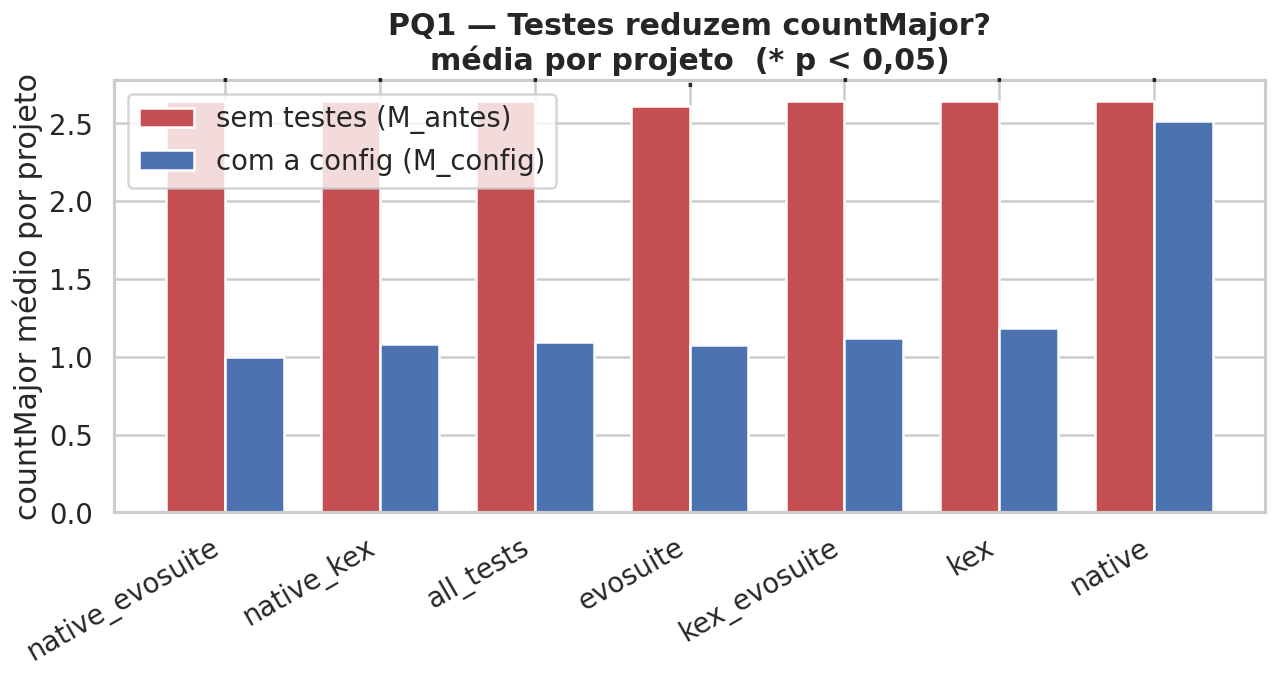

In [17]:
order = pq_summary.sort_values("reducao_rel_media", ascending=False)["config"].tolist()
x = np.arange(len(order))
w = 0.38
antes_vals = [S.loc[c, "media_antes"] for c in order]
config_vals = [S.loc[c, "media_config"] for c in order]

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w / 2, antes_vals, w, label="sem testes (M_antes)", color=COR_ANTES)
ax.bar(x + w / 2, config_vals, w, label="com a config (M_config)", color=COR_CONFIG)
for i, c in enumerate(order):
    if S.loc[c, "significativo"]:
        ax.text(x[i], max(antes_vals[i], config_vals[i]) * 1.03, ".",
                ha="center", va="bottom", fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("countMajor médio por projeto")
ax.set_title("PQ1 — Testes reduzem countMajor?\nmédia por projeto  (* p < 0,05)")
ax.legend()
plt.tight_layout()
plt.show()

## 4.4 PQ1 — Distribuição das reduções por projeto

Cada ponto é um projeto: `countMajor` sem testes − com a configuração. Acima da linha
vermelha (0) = os testes reduziram `countMajor` naquele projeto.

/tmp/ipykernel_1150/1498052643.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=30, ha="right")


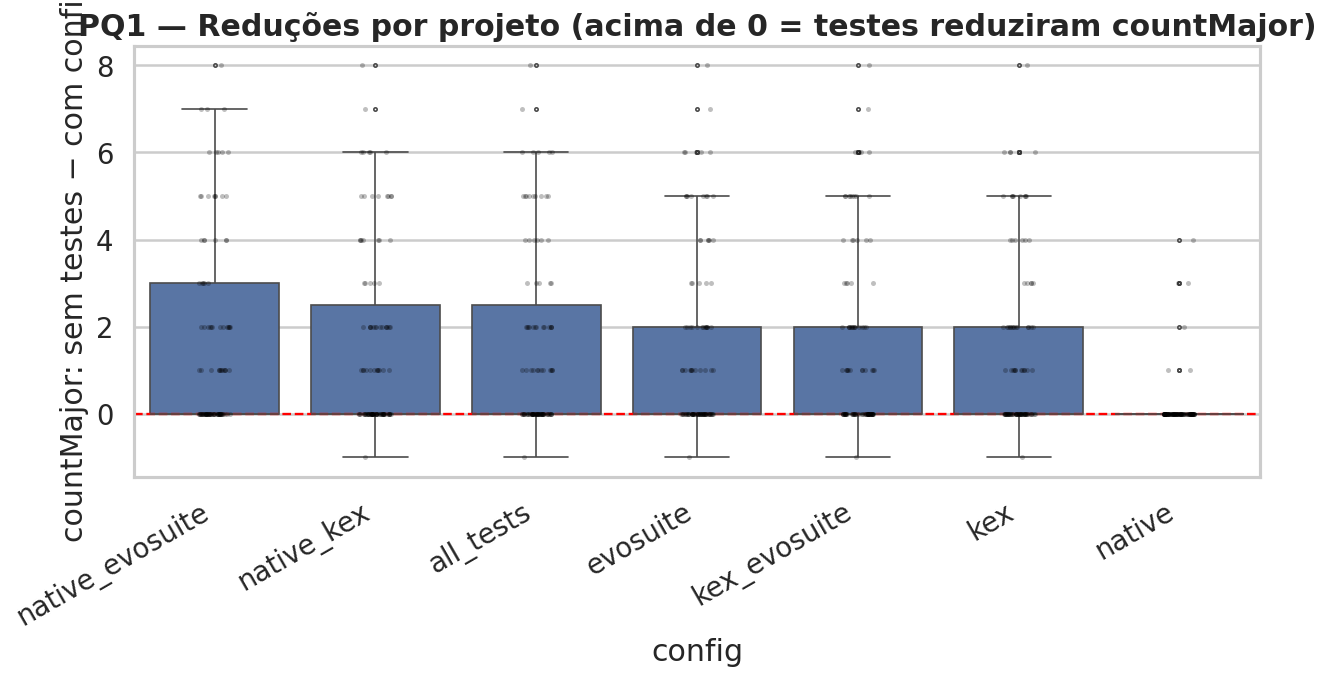

In [18]:
box_rows = []
for nome, res in wilcoxon_results.items():
    paired = res["paired"]
    diff = paired["countMajor_antes"] - paired["countMajor_config"]
    for v in diff:
        box_rows.append({"config": nome, "reducao": v})
box_df = pd.DataFrame(box_rows)

fig, ax = plt.subplots(figsize=(11, 6))
if HAS_SNS:
    sns.boxplot(data=box_df, x="config", y="reducao", order=order,
                color=COR_CONFIG, fliersize=2, ax=ax)
    sns.stripplot(data=box_df, x="config", y="reducao", order=order,
                  color="black", alpha=0.25, size=3, ax=ax)
else:
    ax.boxplot([box_df.loc[box_df["config"] == c, "reducao"] for c in order], labels=order)
ax.axhline(0, color="red", lw=1.4, ls="--")
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("countMajor: sem testes − com config")
ax.set_title("PQ1 — Reduções por projeto (acima de 0 = testes reduziram countMajor)")
plt.tight_layout()
plt.show()

## 4.5 PQ2 — Ranking de redução relativa média

Qual configuração reduz proporcionalmente mais `countMajor`. `native` responde à
primeira parte da PQ2 (a suíte existente basta?); as combinações, à segunda.

salvo: fig_pq2.pdf


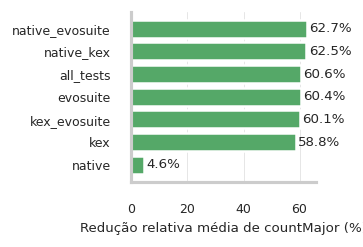

In [19]:
import seaborn as sns

d = pq_summary.sort_values("reducao_rel_media")
fig, ax = plt.subplots(figsize=(10, 6))
colors = [COR_POS if v > 0 else COR_NEG for v in d["reducao_rel_media"]]
bars = ax.barh(d["config"], d["reducao_rel_media"] * 100, color=colors)
ax.axvline(0, color="black", lw=1)
for bar, v in zip(bars, d["reducao_rel_media"] * 100):
    ax.text(v + (0.8 if v >= 0 else -0.8), bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}%", va="center", ha="left" if v >= 0 else "right", fontsize=11)
ax.set_xlabel("Redução relativa média de countMajor (%)")
ax.set_title("PQ2 — Qual configuração reduz mais countMajor?\n(baseline = without_tests)")
sns.set_style("white")
salvar_para_acm(plt.gcf(), "fig_pq2.pdf")
plt.tight_layout()
plt.show()

## 4.6 PQ1/PQ2 — Tamanho de efeito (rank-biserial) por configuração

`r → 1` = redução consistente entre projetos. Azul = significativo (p < 0,05); cinza = não.
Linhas pontilhadas: limiares 0,1 / 0,3 / 0,5 (small / medium / large).

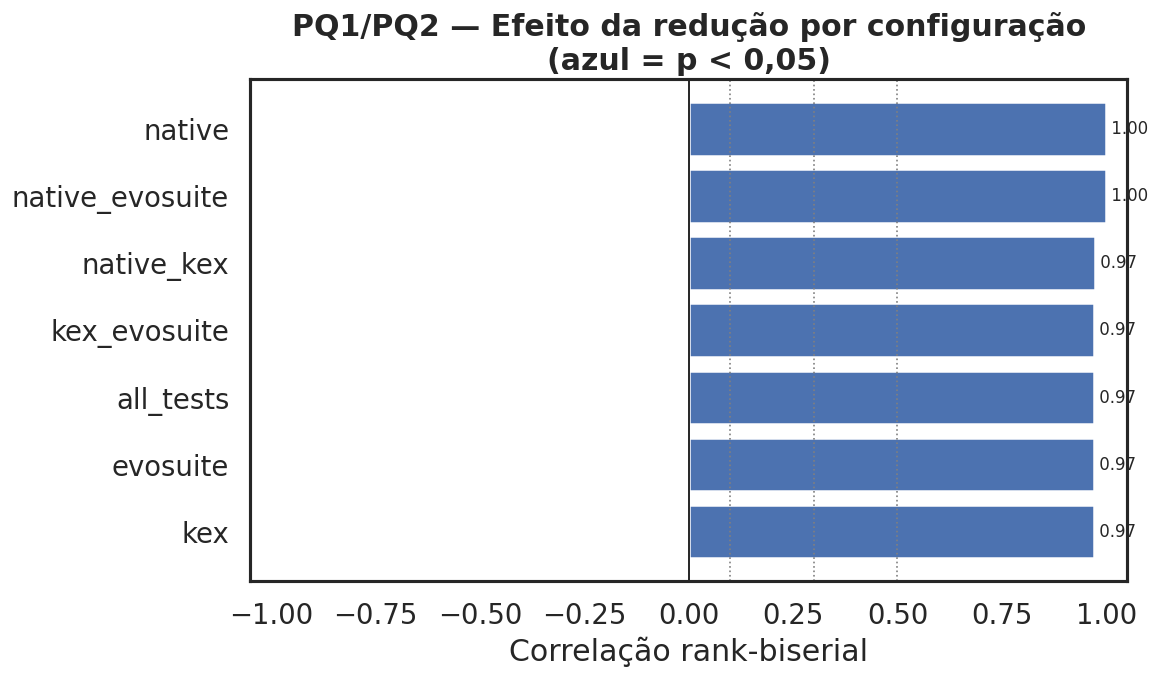

In [20]:
d = pq_summary.sort_values("r_rb")
fig, ax = plt.subplots(figsize=(10, 6))
colors = [COR_CONFIG if s else "#b0b0b0" for s in d["significativo"]]
bars = ax.barh(d["config"], d["r_rb"], color=colors)
ax.axvline(0, color="black", lw=1)
for x0 in (0.1, 0.3, 0.5):
    ax.axvline(x0, color="gray", ls=":", lw=1)
for bar, v in zip(bars, d["r_rb"]):
    if pd.notna(v):
        ax.text(v, bar.get_y() + bar.get_height() / 2, f" {v:.2f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=10)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("Correlação rank-biserial")
ax.set_title("PQ1/PQ2 — Efeito da redução por configuração\n(azul = p < 0,05)")
plt.tight_layout()
plt.show()

## 4.7 Cobertura × redução relativa (Spearman)

Barras: `rho` de Spearman por configuração (instruction e branch). Depois, dispersões
por configuração com linha de tendência, `rho`, `p` e N.

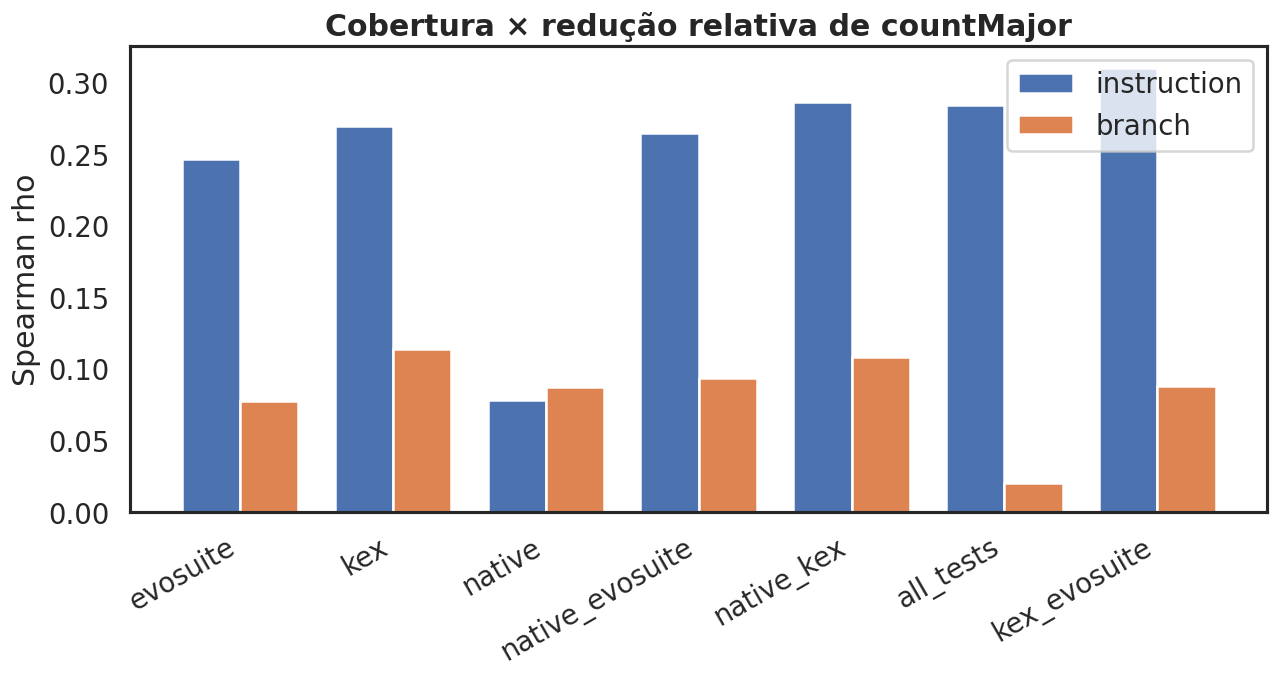

In [21]:
if not spearman_summary.empty:
    d = spearman_summary.set_index("config")
    x = np.arange(len(d))
    w = 0.38
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - w / 2, d["rho_instruction_coverage"], w, label="instruction", color=COR_CONFIG)
    ax.bar(x + w / 2, d["rho_branch_coverage"], w, label="branch", color="#dd8452")
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(d.index, rotation=30, ha="right")
    ax.set_ylabel("Spearman rho")
    ax.set_title("Cobertura × redução relativa de countMajor")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Sem dados de Spearman suficientes para o gráfico.")

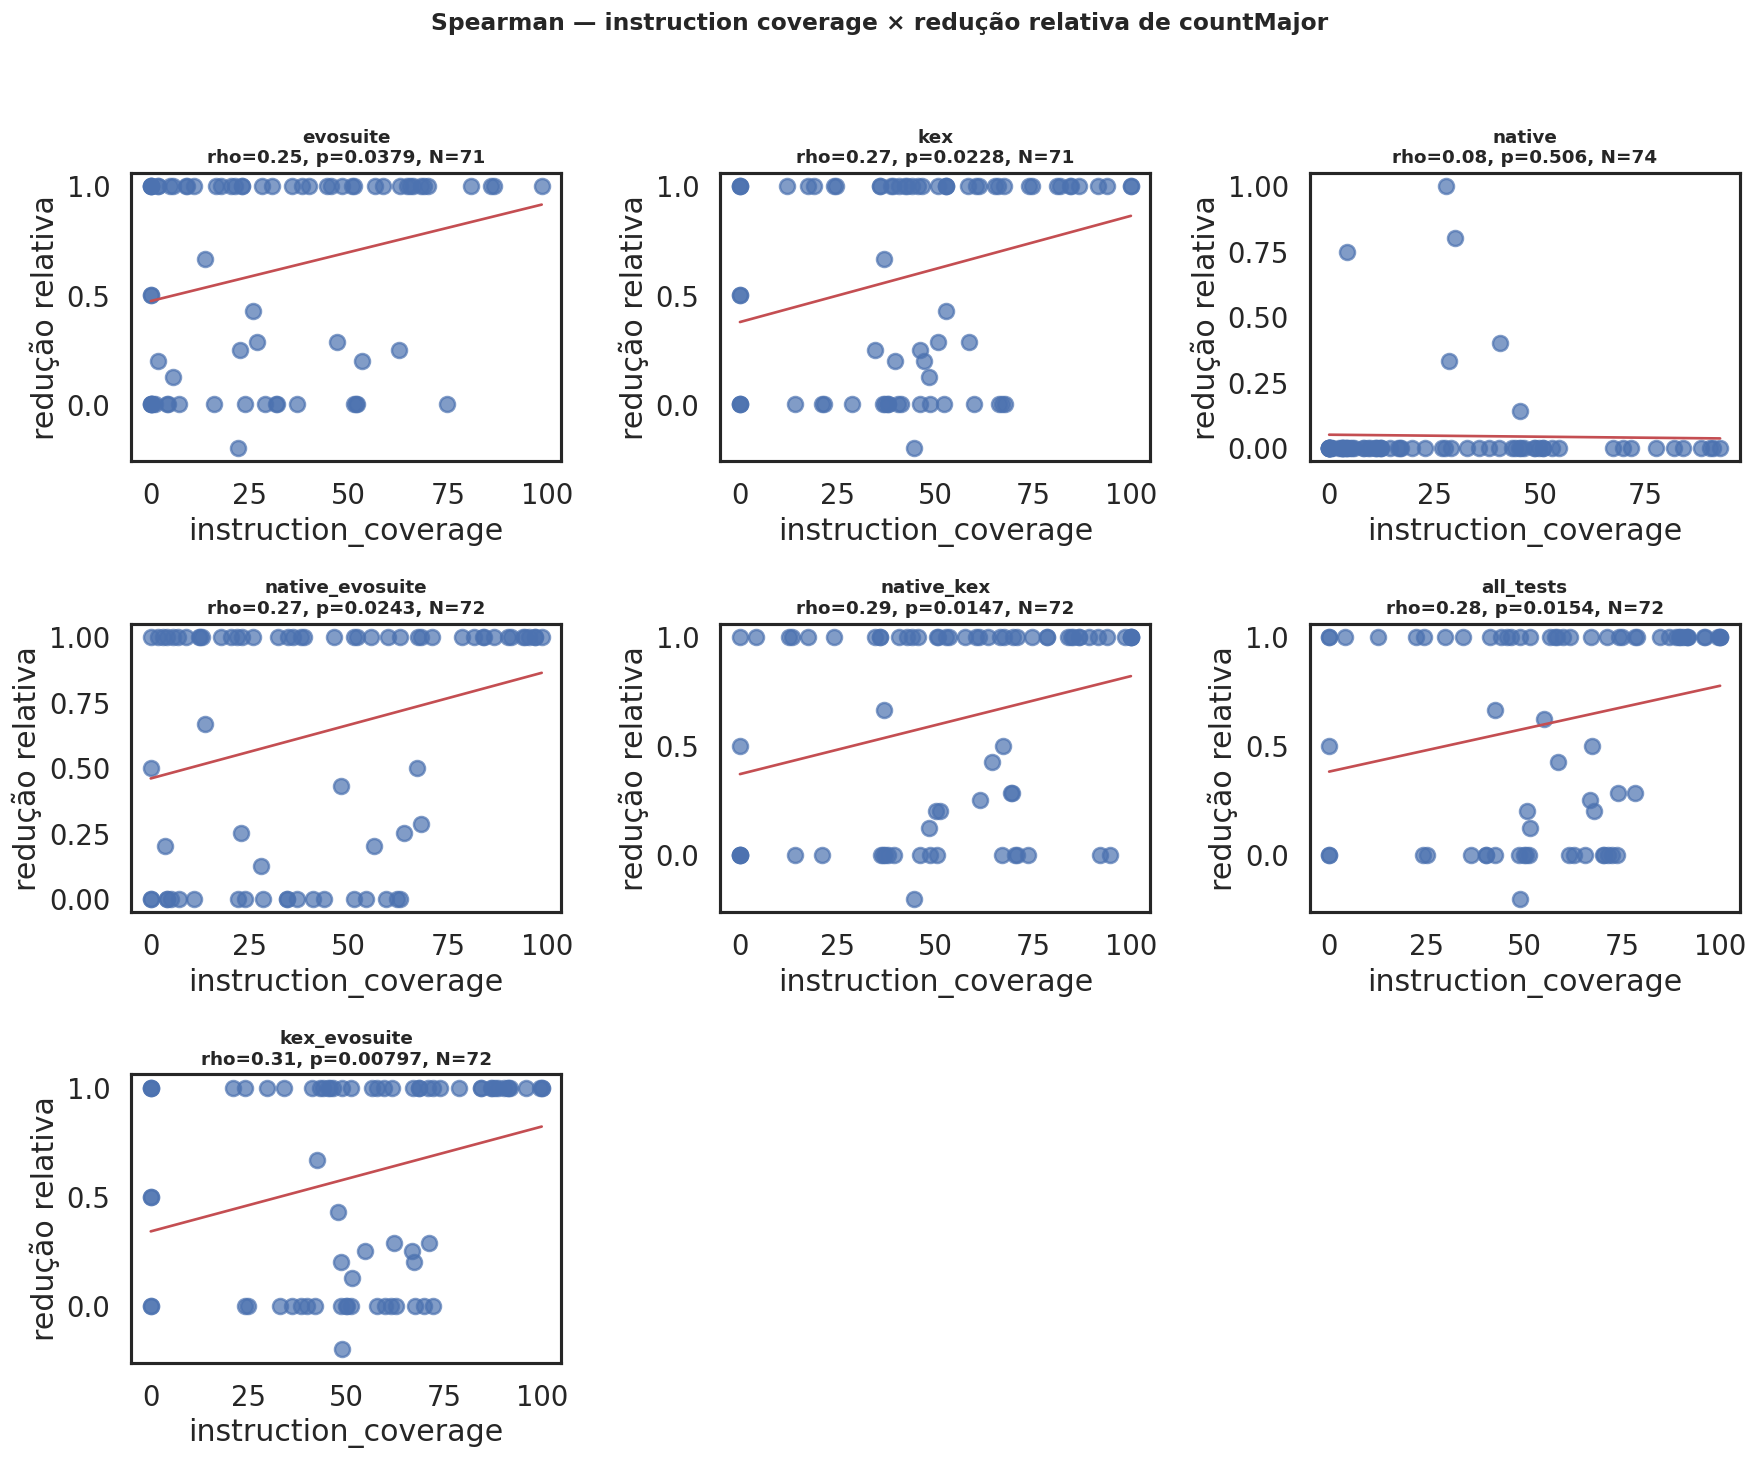

In [22]:
cfgs_ok = [n for n in configs if n in spearman_results and len(spearman_results[n]) >= 3]
if cfgs_ok:
    ncol = 3
    nrow = int(np.ceil(len(cfgs_ok) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4 * nrow), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for i, nome in enumerate(cfgs_ok):
        ax = axes[i // ncol][i % ncol]
        ax.axis("on")
        m = spearman_results[nome]
        ax.scatter(m["instruction_coverage"], m["reducao_relativa"],
                   alpha=0.7, color=COR_CONFIG)
        if m["instruction_coverage"].nunique() > 1:
            z = np.polyfit(m["instruction_coverage"], m["reducao_relativa"], 1)
            xs = np.linspace(m["instruction_coverage"].min(), m["instruction_coverage"].max(), 50)
            ax.plot(xs, np.polyval(z, xs), color=COR_ANTES, lw=1.6)
        rho, p = spearmanr(m["instruction_coverage"], m["reducao_relativa"])
        ax.set_title(f"{nome}\nrho={rho:.2f}, p={p:.3g}, N={len(m)}", fontsize=11)
        ax.set_xlabel("instruction_coverage")
        ax.set_ylabel("redução relativa")
    fig.suptitle("Spearman — instruction coverage × redução relativa de countMajor",
                 y=1.02, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma configuração com N >= 3 projetos com cobertura.")

## 4.8 Como ler os gráficos (resumo)

- **PQ1** (4.3 e 4.4): barras azuis mais baixas e pontos acima de 0 indicam que os testes
  reduziram `countMajor`. O `*` e o tamanho de efeito (4.6) dizem se a redução é sistemática.
- **PQ2** (4.5 e 4.6): a configuração no topo do ranking reduz mais. Compare `native`
  (suíte existente) com as combinações para ver se a geração automática agrega.
- **Cobertura** (4.7): `rho` positivo sugere que projetos com mais cobertura reduzem
  proporcionalmente mais; confira o `p` e o N (poucos projetos → conclua com cautela).

> Nota sobre `countMajor = '-'`: o parser emite `'-'` quando não conseguiu ler o log; aqui
> esses valores viram NaN e são ignorados (não contam como 0). As variantes `native_evosuite`
> e `native_kex` foram carregadas na Célula 1 com `'-' → 0.0`; para tratamento idêntico ao
> das demais, recarregue-as sem `fillna(0.0)`.